In [1]:
import os
import sys
import pandas as pd
import yaml 
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import statsmodels.api as sm
import numpy as np
from itertools import product
import subprocess

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 11
#plt.rcParams['text.usetex'] = True


with open("../../config.yaml.local", "r") as f:
    LOCAL_CONFIG = yaml.safe_load(f)
with open("../../config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)
sys.path.append("../python")

import globals
import data_tools as dt
import writing_tools as wt
import utils

LOCAL_PATH = LOCAL_CONFIG["LOCAL_PATH"]
RAW_DATA_PATH = LOCAL_CONFIG["RAW_DATA_PATH"]
DATA_PATH = LOCAL_CONFIG["DATA_PATH"]
R_PATH = LOCAL_CONFIG["R_PATH"]

RUN_R_SCRIPTS = False

RESULTS = {}

In [2]:
qual_df = pd.read_parquet(os.path.join(DATA_PATH, "post_quality_analysis_data.parquet"))
quant_df = pd.read_parquet(os.path.join(DATA_PATH, "post_quantity_analysis_data.parquet"))
territory_df = dt.get_territory_by_day_panel()  # territory-by-day


In [3]:
# Calculate fee_diff_{jt} = fee_{jt} - fee_{j,t-1}

territory_df["fee_diff"] = territory_df.groupby("subName")["posting_fee"].diff()
territory_df["fee_chg_pos"] = (territory_df["fee_diff"] > 0).astype(int)
territory_df["fee_chg_neg"] = (territory_df["fee_diff"] < 0).astype(int)


In [4]:
# territory-by-week

twdf = territory_df.copy()
twdf["week"] = dt.as_week(twdf["date"])
twdf = twdf.groupby(["subName", "week"]).agg(
    fee_chg_pos = ("fee_chg_pos", "max"),
    fee_chg_neg = ("fee_chg_neg", "max")
).reset_index()



c:\Users\edwar\projects\sn-research\src\notebooks\../python\data_tools.py:91: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  return x.dt.to_period('W-SAT').dt.start_time


In [5]:
# leads and lags for fee_chg_pos and fee_chg_neg
K = 12
for s in range(1,K+1):
    twdf[f"fee_chg_pos_F{s}"] = twdf.groupby("subName")["fee_chg_pos"].shift(-s)
    twdf[f"fee_chg_neg_F{s}"] = twdf.groupby("subName")["fee_chg_neg"].shift(-s)
    twdf[f"fee_chg_pos_L{s}"] = twdf.groupby("subName")["fee_chg_pos"].shift(s)
    twdf[f"fee_chg_neg_L{s}"] = twdf.groupby("subName")["fee_chg_neg"].shift(s)



In [6]:
# Quality df for analysis

qual_df = qual_df.merge(twdf, on=["subName", "week"], how="left")

# output for processing in R
qual_df.to_parquet(os.path.join(DATA_PATH, "pretrends_check_qual_df.parquet"), index=False)


In [7]:
# Quantity df for analysis

quant_df = quant_df.merge(twdf, on=["subName", "week"], how="left")
quant_df = quant_df.sort_values(by=['subId', 'weekId'])
quant_df['L12_growth'] = np.log(1+quant_df.groupby('subId')['n_posts'].shift(1)) - np.log(1+quant_df.groupby('subId')['n_posts'].shift(12))  # territory growth in posts from 12 weeks ago

# output for processing in R
quant_df.to_parquet(os.path.join(DATA_PATH, "pretrends_check_quant_df.parquet"), index=False)


In [8]:
res = subprocess.run([R_PATH, LOCAL_PATH + "/src/R/06_pretrends_analysis.R"], capture_output=True, text=True, check=True)
print(res.stdout)

                                r1                  r2                  r3
Dependent Var.:         log_sats48          log_sats48           log_posts
                                                                          
fee_chg_pos_F12   -0.1390 (0.1061)    -0.1058 (0.0802)    0.2074. (0.1216)
fee_chg_pos_F11 -0.4094** (0.1338)   -0.2018. (0.1011)    0.3076* (0.1234)
fee_chg_pos_F10 -0.4497** (0.1632)   -0.2528* (0.1107)   0.3756** (0.1209)
fee_chg_pos_F9  -0.3756** (0.1306)   -0.1826* (0.0785)    0.2719. (0.1403)
fee_chg_pos_F8  -0.4324** (0.1563)  -0.3147** (0.0981)    0.3213* (0.1478)
fee_chg_pos_F7   -0.3404. (0.1782)   -0.2153* (0.0989)   0.4109** (0.1268)
fee_chg_pos_F6   -0.3237. (0.1800)   -0.2044. (0.1109)   0.3628** (0.1241)
fee_chg_pos_F5   -0.3405* (0.1378)  -0.2227** (0.0809)   0.3666** (0.1253)
fee_chg_pos_F4  -0.4379** (0.1359) -0.2845*** (0.0731)  0.4627*** (0.1227)
fee_chg_pos_F3  -0.4263** (0.1572)  -0.2474** (0.0886)  0.4846*** (0.1339)
fee_chg_pos_F2   -0.3487*

In [9]:
coefs_df = pd.read_parquet(os.path.join(DATA_PATH, "pretrends_analysis_coefs.parquet"))

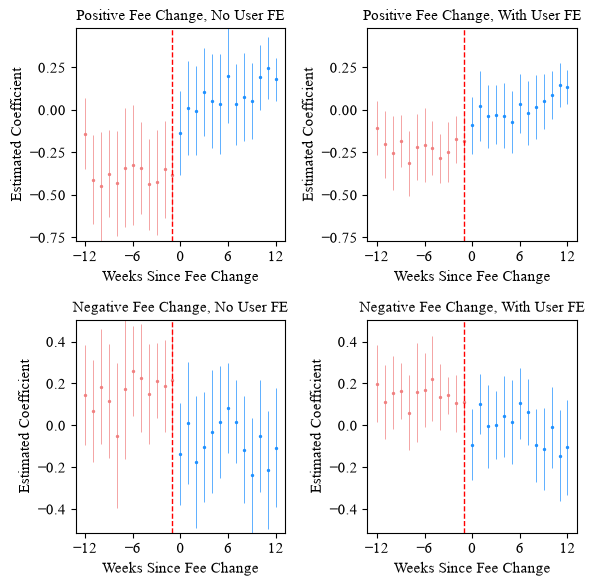

In [10]:
# Quality event studies

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for i, posneg in zip([0,1], ["pos", "neg"]):
    for j, regname in zip([0,1], ["r1", "r2"]):
        coef_names = [f"fee_chg_{posneg}_F{k}" for k in range(12,0,-1)] + ["fee_chg_pos"] + [f"fee_chg_{posneg}_L{k}" for k in range(1,13)]
        y = []
        ylb = []
        yub = []
        for coef in coef_names:
            mask = (coefs_df["regression_name"]==regname) & (coefs_df["coef_name"]==coef)
            if mask.sum() == 0:
                y.append(np.nan)
                ylb.append(np.nan)
                yub.append(np.nan)
                continue
            my_y = coefs_df.loc[mask, "estimate"].values[0]
            my_ylb = my_y - 1.96*coefs_df.loc[mask, "serr"].values[0]
            my_yub = my_y + 1.96*coefs_df.loc[mask, "serr"].values[0]
            y.append(my_y)
            ylb.append(my_ylb)
            yub.append(my_yub)
        y = np.array(y)
        ylb = np.array(ylb)
        yub = np.array(yub)
        x = np.arange(-12, 13)
        if j==0:
            yscale_lb = np.min(ylb)
            yscale_ub = np.max(yub)
        axes[i, j].scatter(x[x<0], y[x<0], s=2, color='lightcoral')
        axes[i, j].errorbar(x[x<0], y[x<0], yerr=[y[x<0] - ylb[x<0], yub[x<0] - y[x<0]], fmt='none', ecolor='lightcoral', elinewidth=0.5)
        axes[i, j].scatter(x[x>=0], y[x>=0], s=2, color='dodgerblue')
        axes[i, j].errorbar(x[x>=0], y[x>=0], yerr=[y[x>=0] - ylb[x>=0], yub[x>=0] - y[x>=0]], fmt='none', ecolor='dodgerblue', elinewidth=0.5)
        axes[i,j].axvline(-1, color="red", linestyle="--", linewidth=1)
        axes[i,j].set_ylim(yscale_lb, yscale_ub)
        axes[i,j].set_xticks(np.arange(-12, 13, 6))
        if i==0:
            title = "Positive Fee Change"
        else:
            title = "Negative Fee Change"
        if j==0:
            title += ", No User FE"
        else:
            title += ", With User FE"
        axes[i,j].set_title(title, fontsize=11)
        axes[i,j].set_ylabel("Estimated Coefficient")
        axes[i,j].set_xlabel("Weeks Since Fee Change")

#plt.suptitle("Post Quality Event Study")
plt.tight_layout()
plt.savefig(os.path.join(LOCAL_PATH, "results", "fig_post_quality_event_study.pdf"), bbox_inches='tight')

tex = r"""
\begin{figure}[H]
\caption{Post Quality Event Study}
\label{fig_post_quality_event_study}
\vspace{-0.6cm}
\begin{center}
\begin{adjustbox}{width=\textwidth}
\includegraphics{results/fig_post_quality_event_study.pdf}
\end{adjustbox}
\end{center}
\footnotesize \textit{Note:} Shows estimated coefficients and 95\% confidence intervals from the post quality event study regression specified by equation \eqref{eq_post_quality_event_study}. All regressions shown include territory fixed effects and week fixed effects. 
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "results", "fig_post_quality_event_study.tex"), "w") as f:
    f.write(tex)


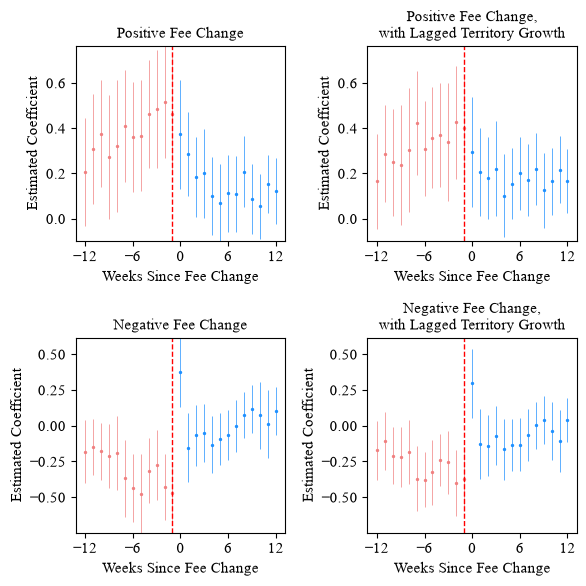

In [11]:
# Quantity event studies

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

for i, posneg in zip([0,1], ["pos", "neg"]):
    for j, regname in zip([0,1], ["r3", "r4"]):
        coef_names = [f"fee_chg_{posneg}_F{k}" for k in range(12,0,-1)] + ["fee_chg_pos"] + [f"fee_chg_{posneg}_L{k}" for k in range(1,13)]
        y = []
        ylb = []
        yub = []
        for coef in coef_names:
            mask = (coefs_df["regression_name"]==regname) & (coefs_df["coef_name"]==coef)
            if mask.sum() == 0:
                y.append(np.nan)
                ylb.append(np.nan)
                yub.append(np.nan)
                continue
            my_y = coefs_df.loc[mask, "estimate"].values[0]
            my_ylb = my_y - 1.96*coefs_df.loc[mask, "serr"].values[0]
            my_yub = my_y + 1.96*coefs_df.loc[mask, "serr"].values[0]
            y.append(my_y)
            ylb.append(my_ylb)
            yub.append(my_yub)
        y = np.array(y)
        ylb = np.array(ylb)
        yub = np.array(yub)
        x = np.arange(-12, 13)
        if j==0:
            yscale_lb = np.min(ylb)
            yscale_ub = np.max(yub)
        axes[i,j].scatter(x[x<0], y[x<0], s=2, color='lightcoral')
        axes[i,j].errorbar(x[x<0], y[x<0], yerr=[y[x<0] - ylb[x<0], yub[x<0] - y[x<0]], fmt='none', ecolor='lightcoral', elinewidth=0.5)
        axes[i,j].scatter(x[x>=0], y[x>=0], s=2, color='dodgerblue')
        axes[i,j].errorbar(x[x>=0], y[x>=0], yerr=[y[x>=0] - ylb[x>=0], yub[x>=0] - y[x>=0]], fmt='none', ecolor='dodgerblue', elinewidth=0.5)
        axes[i,j].axvline(-1, color="red", linestyle="--", linewidth=1)
        axes[i,j].set_ylim(yscale_lb, yscale_ub)
        axes[i,j].set_xticks(np.arange(-12, 13, 6))
        if i==0:
            title = "Positive Fee Change"
        else:
            title = "Negative Fee Change"
        if j==1:
            title += ",\nwith Lagged Territory Growth"
        axes[i,j].set_title(title, fontsize=11)
        axes[i,j].set_ylabel("Estimated Coefficient")
        axes[i,j].set_xlabel("Weeks Since Fee Change")

#plt.suptitle("Post Quantity Event Study")
plt.tight_layout()
plt.savefig(os.path.join(LOCAL_PATH, "results", "fig_post_quantity_event_study.pdf"), bbox_inches='tight')

tex = r"""
\begin{figure}[H]
\caption{Post Quantity Event Study}
\label{fig_post_quantity_event_study}
\vspace{-0.6cm}
\begin{center}
\begin{adjustbox}{width=\textwidth}
\includegraphics{results/fig_post_quantity_event_study.pdf}
\end{adjustbox}
\end{center}
\footnotesize \textit{Note:} Shows estimated coefficients and 95\% confidence intervals from the post quantity event study regression specified by equation \eqref{eq_post_quantity_event_study}. All regressions shown include territory fixed effects and week fixed effects. 
\end{figure}
"""
with open(os.path.join(LOCAL_PATH, "results", "fig_post_quantity_event_study.tex"), "w") as f:
    f.write(tex)
